# What the categorical encoding costs on Criteo

Criteo's 39 features split 13 integer and 26 categorical, and the categorical
26 are the ones a loader has to make a decision about. This notebook prices
three decisions against each other under one protocol:

- **numeric only** — `load_criteo(features="numeric")`. The 26 categorical
  columns are dropped. 13 features.
- **frequency** — `load_criteo(features="all")`. Each categorical column is
  replaced by one float, the relative frequency of that row's category in the
  training split, so two categories that occur equally often become the same
  number. 39 features.
- **one-hot** — `load_criteo_one_hot` (ADR-0020). Each categorical column
  becomes a block of indicator coordinates at its native train-split
  cardinality. 551,947 features, of which a row occupies 39.

Each is run twice: once with **non-private SGD**, which is that encoding's
ceiling, and once with **DP-SGD** (Abadi et al., 2016,
[arXiv:1607.00133](https://arxiv.org/abs/1607.00133)) at ε = 1, δ = 1e-7. Six
cells, one protocol, and two questions that the six answer together — what the
encoding is worth, and how that compares to what privacy costs.

The question is not idle. The library's notebooks were written on the
frequency encoding first and the one-hot loader arrived later, so what the
choice was worth had never been measured; ADR-0020 argued the encoding from
the sparsity assumption `bias_reduced_sgd` needs, which is a different reason
and does not imply this one.

**What is held**, and it is nearly everything: the same file, the same split
seed and test fraction — the three loaders cut the split through the same
`_read_frame` and `_split_frame`, so these are literally the same rows — the
same held-out 100,000 validation rows, the same 200,000 test rows, the same
model, the same per-sample loss, the same optimizer, the same step count, the
same expected lot, the same budget, the same accountant, the same selection
rule, and the same five scores.

**What is not**, in full:

- **The dimension.** It is the axis under test.
- **The initialization**, which is the same rule — `init_params` at the same
  key — over a different width, and cannot be the same vector when the width
  is what changes.
- **Standardization.** The two dense arms centre and scale their columns; the
  one-hot arm does not, because centring a one-hot column fills it and the
  sparsity is what makes the encoding fit at all (ADR-0020). This is the one
  confound the protocol cannot remove, and section 7 says which way it cuts.
- **The tuning each arm receives is the same grid, not the same point.** Every
  arm searches an identical `C` × learning-rate grid and keeps its own best on
  validation log-loss, because a shared point would price the point rather
  than the encoding.

In [1]:
import os

# The grids below run configurations concurrently on one device and the pool
# is sized against what the allocator will hand out (section 5). JAX reads
# this once, at import, and takes 75% of the device without it. Below that
# because this card is shared.
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", "0.62")

import time
from concurrent.futures import ThreadPoolExecutor
from typing import Callable, NamedTuple

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from dimma.accounting.sampling import (
    PoissonGaussianSchedule,
    calibrate_noise_multiplier,
    poisson_gaussian_epsilon,
)
from dimma.algorithms.dp_sgd import train as dp_sgd
from dimma.algorithms.sgd import train as sgd
from dimma.core import gradients, updates
from dimma.core.sampling import poisson
from dimma.datasets.criteo import load_criteo, load_criteo_one_hot
from dimma.metrics.calibration import (
    calibration_ratio,
    expected_calibration_error,
)
from dimma.metrics.decomposition import log_loss_decomposition
from dimma.metrics.operating_point import Confusion, confusion_at
from dimma.metrics.ranking import pr_curve
from dimma.metrics.scoring import log_loss, normalized_entropy
from dimma.models.logreg import forward, forward_sparse, init_params
from dimma.models.losses import per_sample_bce_loss

DEVICE = "gpu" if any(d.platform == "gpu" for d in jax.devices()) else "cpu"
print(f"jax devices: {jax.devices()}  ->  DEVICE = {DEVICE!r}")

# One colour per encoding, held across every table and figure below. The
# three clear the colour-vision and normal-vision separation floors as a set.
INK, MUTED, SURFACE = "#0b0b0b", "#52514e", "#fcfcfb"
NUMERIC_C, FREQUENCY_C, ONE_HOT_C = "#eb6834", "#52514e", "#2a78d6"
BASELINE_C = "#1baf7a"

jax devices: [CudaDevice(id=0)]  ->  DEVICE = 'gpu'


In [2]:
SMOKE = False            # flip to True for a minutes-long shape check

# ---- the protocol, identical across all six cells -----------------------
TARGET_EPSILON = 1.0
TARGET_DELTA = 1e-7
STEPS = 3_000
EXPECTED_BATCH_SIZE = 1024   # exact for plain SGD, expected for DP-SGD's lots

TEST_FRACTION = 0.2
VALIDATION_ROWS = 100_000    # cut off the 800,000 training rows
SPLIT_SEED = 0               # the rows, identical across the three loaders
INIT_SEED = 0                # the initialization rule, at every width
BASE_SEED = 20260823         # sampling and noise streams move off this
FEATURE_NORM_BOUND = None    # DP-SGD's sensitivity is the clip, not the row
N_BINS = 15

# One grid, searched by every arm. It has to bracket three encodings at once,
# so it is wider than any single-encoding notebook's: the clip runs from well
# under the smallest per-sample gradient norm section 4 measures to well over
# the largest, and the learning rate spans two decades.
CLIP_GRID = (1.0, 3.0, 10.0)
LEARNING_RATE_GRID = (0.01, 0.1, 1.0)

if SMOKE:
    STEPS = 30
    VALIDATION_ROWS = 20_000
    CLIP_GRID, LEARNING_RATE_GRID = (3.0,), (0.1,)
    print("SMOKE: a shape check, not the run this file carries\n")

print(f"epsilon = {TARGET_EPSILON} at delta = {TARGET_DELTA}, "
      f"{STEPS:,} steps, expected lot {EXPECTED_BATCH_SIZE:,}")
print(f"grid per arm: {len(CLIP_GRID)} clips x "
      f"{len(LEARNING_RATE_GRID)} learning rates")

epsilon = 1.0 at delta = 1e-07, 3,000 steps, expected lot 1,024
grid per arm: 3 clips x 3 learning rates


## 1. The three encodings

Three loads of the same file. The two dense modes come back as matrices; the
one-hot mode comes back as index/value pairs and a width, because the matrix it
implies is 2.2 TB (ADR-0020). Everything the three have in common — the rows,
the split, the integer-column chain of median fill, clip and `log1p` — is
common because it is the same code, not because three call sites agree.

In [3]:
numeric_split = load_criteo(features="numeric", preprocess=True,
                            standardize=True, download=False,
                            test_fraction=TEST_FRACTION, seed=SPLIT_SEED,
                            device=DEVICE,
                            feature_norm_bound=FEATURE_NORM_BOUND)
frequency_split = load_criteo(features="all", preprocess=True,
                              standardize=True, download=False,
                              test_fraction=TEST_FRACTION, seed=SPLIT_SEED,
                              device=DEVICE,
                              feature_norm_bound=FEATURE_NORM_BOUND)
one_hot_split = load_criteo_one_hot(preprocess=True, download=False,
                                    test_fraction=TEST_FRACTION,
                                    seed=SPLIT_SEED, device=DEVICE,
                                    feature_norm_bound=FEATURE_NORM_BOUND)

assert (np.asarray(numeric_split.y_test)
        == np.asarray(one_hot_split.y_test)).all(), "test rows differ"
assert (np.asarray(frequency_split.y_test)
        == np.asarray(one_hot_split.y_test)).all(), "test rows differ"

base_rate = float(one_hot_split.y_test.mean())
print(f"\nsame {len(one_hot_split.y_test):,} test rows in all three, "
      f"base rate {base_rate:.4f}")
print(f"PR-AUC floor (a random ranking scores the base rate): {base_rate:.4f}")

criteo: 13 integer features I1-I13: NaN filled with the train-split median, clipped below at 0, then log1p. The stored values carry no NaN and no negatives, so the fill and the clip are no-ops here and log1p acts on [0, 1]. Every column then standardized by the train-split mean and standard deviation.


criteo: 39 features. I1-I13: NaN filled with the train-split median, clipped below at 0, log1p — the fill and the clip are no-ops on stored values that carry neither NaN nor negatives, and log1p acts on [0, 1]. C1-C26: each category ID replaced by that category's relative frequency in the train split, with categories unseen in training encoded as 0.0. Every column then standardized by the train-split mean and standard deviation.



same 200,000 test rows in all three, base rate 0.2520
PR-AUC floor (a random ranking scores the base rate): 0.2520


criteo: 39 features as index/value pairs. I1-I13 at indices 0-12: NaN filled with the train-split median, clipped below at 0, then log1p — the fill and the clip are no-ops on stored values that carry neither NaN nor negatives, and log1p acts on [0, 1]. C1-C26 one-hot at their native train-split cardinalities, each column holding its own block of the index space and one slot reserved for IDs unseen in the training split, so every row carries exactly 39 entries whatever it holds. Not standardized: centring a one-hot column fills it, and the sparsity is the point.


A dimma per-sample loss is `(params, x_single, y_single) -> scalar` and a
training loop slices its `x` along one leading axis, so the one-hot arm's two
arrays travel as one: the first 39 columns are the indices, the last 39 the
values, and the sparse loss below unpacks them. Indices go through float32
exactly — the widest is 551,946, well inside the 16,777,216 where float32 stops
counting by ones — and the assertion is what says so. This is the
bias-reduced-SGD sweep's cell and the DP-SGD sweep's, because all three are
packing the same split for the same loop.

The dense arms use `dimma.models.losses.per_sample_bce_loss` over `forward`
unchanged. The two losses compute the same thing on the same model: the
sparse one gathers 39 weights where the dense one dots `d` of them.

**The validation split** is the last `VALIDATION_ROWS` of the training rows,
cut identically in all three arms because it is a cut of the same permutation.
Every selection below reads it and nothing else; the test rows are not read
until section 7.

In [4]:
STORED_PER_ROW = one_hot_split.idx_train.shape[1]

one_hot_packed_train = jnp.concatenate(
    [one_hot_split.idx_train.astype(jnp.float32), one_hot_split.val_train],
    axis=1,
)
one_hot_packed_test = jnp.concatenate(
    [one_hot_split.idx_test.astype(jnp.float32), one_hot_split.val_test],
    axis=1,
)
assert (np.asarray(one_hot_packed_train[:, :STORED_PER_ROW]).astype(np.int64)
        == np.asarray(one_hot_split.idx_train)).all(), "index round-trip"


def per_sample_sparse_bce(params, packed, y):
    """BCE for one example held as concatenated indices and values."""
    idx = packed[:STORED_PER_ROW].astype(jnp.int32)
    val = packed[STORED_PER_ROW:]
    logit = forward_sparse(params, idx, val)
    return jax.nn.softplus(logit) - logit * y


def forward_packed(params, packed):
    """The logit for one packed sparse row, for scoring."""
    idx = packed[:STORED_PER_ROW].astype(jnp.int32)
    return forward_sparse(params, idx, packed[STORED_PER_ROW:])


class Encoding(NamedTuple):
    """One representation of the same rows, ready to train and score."""

    name: str
    colour: str
    width: int
    """`d`, the number of parameters a model over this encoding carries."""
    x_train: jax.Array
    y_train: jax.Array
    x_val: jax.Array
    y_val: jax.Array
    x_test: jax.Array
    loss_fn: Callable
    forward_fn: Callable


def split_off_validation(x, y, x_test, name, colour, width, loss_fn,
                         forward_fn):
    """Cut the last `VALIDATION_ROWS` training rows off as validation."""
    cut = x.shape[0] - VALIDATION_ROWS
    return Encoding(
        name=name, colour=colour, width=width,
        x_train=x[:cut], y_train=y[:cut],
        x_val=x[cut:], y_val=y[cut:],
        x_test=x_test, loss_fn=loss_fn, forward_fn=forward_fn,
    )


ENCODINGS = (
    split_off_validation(
        numeric_split.x_train, numeric_split.y_train, numeric_split.x_test,
        "numeric only", NUMERIC_C, int(numeric_split.x_train.shape[1]),
        per_sample_bce_loss, forward,
    ),
    split_off_validation(
        frequency_split.x_train, frequency_split.y_train,
        frequency_split.x_test,
        "frequency", FREQUENCY_C, int(frequency_split.x_train.shape[1]),
        per_sample_bce_loss, forward,
    ),
    split_off_validation(
        one_hot_packed_train, one_hot_split.y_train, one_hot_packed_test,
        "one-hot", ONE_HOT_C, int(one_hot_split.num_features),
        per_sample_sparse_bce, forward_packed,
    ),
)

N_TRAIN = ENCODINGS[0].x_train.shape[0]
Y_TEST = np.asarray(one_hot_split.y_test, dtype=np.float64)
Y_VAL = np.asarray(ENCODINGS[0].y_val, dtype=np.float64)
THRESHOLD = float(ENCODINGS[0].y_train.mean())

# The three encodings hold the same rows in the same order, so one label
# vector serves all of them. Asserted rather than assumed: a permutation
# difference here would make every comparison below meaningless while
# leaving every number plausible.
for encoding in ENCODINGS[1:]:
    assert (np.asarray(encoding.y_val) == np.asarray(ENCODINGS[0].y_val)).all()
    assert (np.asarray(encoding.y_train)
            == np.asarray(ENCODINGS[0].y_train)).all()

print(f"{'encoding':<14} {'d':>10} {'train':>9} {'val':>8} {'test':>8} "
      f"{'stored/row':>11}")
for encoding in ENCODINGS:
    stored = (STORED_PER_ROW if encoding.name == "one-hot"
              else encoding.width)
    print(f"{encoding.name:<14} {encoding.width:>10,} "
          f"{encoding.x_train.shape[0]:>9,} {VALIDATION_ROWS:>8,} "
          f"{len(Y_TEST):>8,} {stored:>11}")
print(f"\ndecision threshold p >= {THRESHOLD:.4f}, the training base rate")

encoding                d     train      val     test  stored/row
numeric only           13   700,000  100,000  200,000          13
frequency              39   700,000  100,000  200,000          39
one-hot           551,947   700,000  100,000  200,000          39

decision threshold p >= 0.2512, the training base rate


## 2. One budget, one noise multiplier, three dimensions

The accountant does not know the encoding. `q`, `STEPS` and δ are its whole
input, so **all three DP-SGD arms run at the same noise multiplier** — the
Gaussian mechanism's guarantee is stated per release, and the sensitivity
clipping enforces is a norm, not a dimension.

What the dimension changes is what that multiplier does. A step adds
`N(0, σC)` independently to each of `d` coordinates, so the perturbation
vector's length grows like `σ C √d`: the same guarantee, the same per-coordinate
noise, and a displacement of the parameter vector that is 206 times longer at
551,947 coordinates than at 13. The table below is that arithmetic, and it is
the reason to expect the wide encoding to lose — which makes it worth knowing
whether it does.

**δ = 1e-7** is below `1/n` on these 700,000 training rows, which is the
convention DP-SGD's literature reports at. It is not the `1/n²` that
`bias_reduced_sgd`'s preconditions ask for, so the numbers here are not
readable against the bias-reduced-SGD comparison's; that one runs at
δ = 1e-12 and pays a materially noisier mechanism for it.

In [5]:
q = EXPECTED_BATCH_SIZE / N_TRAIN
print(f"sampling rate q = {q:.6f} over {N_TRAIN:,} rows, {STEPS:,} steps")
print(f"1 / n = {1 / N_TRAIN:.3e}, and delta = {TARGET_DELTA:.0e}")

t0 = time.time()
sigma = calibrate_noise_multiplier(
    lambda multiplier: [PoissonGaussianSchedule(q, multiplier, STEPS)],
    TARGET_EPSILON, TARGET_DELTA,
)
spent = poisson_gaussian_epsilon(q, sigma, STEPS, TARGET_DELTA)
print(f"noise multiplier sigma = {sigma:.6f}   ({time.time() - t0:.1f}s)")
print(f"epsilon at that multiplier = {spent:.6f}  "
      f"(target {TARGET_EPSILON})\n")
assert spent <= TARGET_EPSILON + 1e-9

print(f"{'encoding':<14} {'d':>10} {'sqrt(d)':>9} "
      f"{'noise vector at C = 1':>22}")
for encoding in ENCODINGS:
    root = np.sqrt(encoding.width)
    print(f"{encoding.name:<14} {encoding.width:>10,} {root:>9.1f} "
          f"{sigma * root:>22.1f}")

sampling rate q = 0.001463 over 700,000 rows, 3,000 steps
1 / n = 1.429e-06, and delta = 1e-07


noise multiplier sigma = 1.084062   (0.2s)
epsilon at that multiplier = 0.999999  (target 1.0)

encoding                d   sqrt(d)  noise vector at C = 1
numeric only           13       3.6                    3.9
frequency              39       6.2                    6.8
one-hot           551,947     742.9                  805.4


## 3. What one run is scored on

The five numbers are the DP-SGD sweep's, the DP-SGD-vs-SGD-baseline
comparison's and the bias-reduced-SGD comparison's, for the reasons those
notebooks give: **log-loss**, the objective the loop descends and the one
selection reads; **normalized entropy**, which states the constant predictor as 1.0;
**ECE** at 15 equal-mass bins, upward-biased and so comparable only against
itself; the **calibration ratio**; and **PR-AUC**, floored at the base rate.
ROC-AUC appears nowhere: at a 25% base rate it flatters a model that has
learned nothing.

Beside them, in section 7 only, the **log-loss decomposition**. It separates
what a ranking score can see from what it cannot — resolution is how far the
bins pull apart from the base rate, calibration is everything a ranking is
invariant to — which is the tool for saying whether a weaker encoding has lost
the signal or merely states it wrongly.

**The operating point** is the training base rate, fixed before any run,
identical for all six cells, and a training-split statistic rather than a
further read of the test labels.

In [6]:
# One jitted, vmapped forward per encoding, built here rather than on first
# use: the grids below score from several threads at once, and a cache filled
# lazily would have them racing to compile the same function.
SCORERS = {encoding.name: jax.jit(jax.vmap(encoding.forward_fn,
                                           in_axes=(None, 0)))
           for encoding in ENCODINGS}


def scorer(encoding):
    """The jitted, vmapped forward for one encoding."""
    return SCORERS[encoding.name]


class Eval(NamedTuple):
    """Everything one parameter set is scored on, plus what drew it."""

    loss: float
    ne: float
    ece: float
    cal_ratio: float
    pr_auc: float
    confusion: Confusion
    probs: np.ndarray
    """Kept so a figure does not cost a second training run."""


class Selected(NamedTuple):
    """One arm's grid winner: what it was, and how it scored."""

    encoding: str
    arm: str
    clip_norm: float | None
    """`None` for the non-private arm, which has no clipping line."""
    learning_rate: float
    validation: Eval
    test: Eval


def score(params, encoding, x, labels):
    """Score one parameter set on one array of the same encoding."""
    logits = scorer(encoding)(params, x)
    probs = np.asarray(jax.nn.sigmoid(logits), dtype=np.float64)
    return Eval(
        loss=log_loss(probs, labels),
        ne=normalized_entropy(probs, labels),
        ece=expected_calibration_error(probs, labels, n_bins=N_BINS),
        cal_ratio=calibration_ratio(probs, labels),
        pr_auc=pr_curve(probs, labels).average_precision,
        confusion=confusion_at(probs, labels, THRESHOLD),
        probs=probs,
    )


def rates(confusion):
    """Precision and recall (TPR) from a `Confusion`, read by name."""
    flagged = confusion.true_positives + confusion.false_positives
    clicks = confusion.true_positives + confusion.false_negatives
    precision = (confusion.true_positives / flagged if flagged
                 else float("nan"))
    recall = confusion.true_positives / clicks if clicks else float("nan")
    return precision, recall


CONST_PROBS = np.full_like(Y_TEST, THRESHOLD)
CONST = Eval(
    loss=log_loss(CONST_PROBS, Y_TEST),
    ne=normalized_entropy(CONST_PROBS, Y_TEST),
    ece=expected_calibration_error(CONST_PROBS, Y_TEST, n_bins=N_BINS),
    cal_ratio=calibration_ratio(CONST_PROBS, Y_TEST),
    pr_auc=base_rate,
    confusion=confusion_at(CONST_PROBS, Y_TEST, THRESHOLD),
    probs=CONST_PROBS,
)

COLUMNS = f"{'log-loss':>9} {'NE':>7} {'ECE':>7} {'cal-ratio':>10} {'PR-AUC':>7}"


def score_row(label, result, width=26):
    """One row of every summary table below, so they share a shape."""
    return (f"{label:<{width}}{result.loss:9.4f} {result.ne:7.4f} "
            f"{result.ece:7.4f} {result.cal_ratio:10.4f} {result.pr_auc:7.4f}")


print(f"{'':<26}{COLUMNS}")
print(score_row(f"constant at p = {THRESHOLD:.4f}", CONST))
for encoding in ENCODINGS:
    start = init_params(jax.random.key(INIT_SEED), encoding.width)
    print(score_row(f"init, {encoding.name}",
                    score(start, encoding, encoding.x_test, Y_TEST)))

                           log-loss      NE     ECE  cal-ratio  PR-AUC
constant at p = 0.2512       0.5645  1.0000  0.0008     1.0033  0.2520


init, numeric only           0.6912  1.2244  0.2480     0.5040  0.3392


init, frequency              0.6914  1.2248  0.2480     0.5040  0.3066


init, one-hot                0.7004  1.2407  0.2556     0.4965  0.2635


## 4. Where the clip grid has to reach

Clipping acts on per-sample gradient norms, and those are a property of the
encoding: for this linear model the per-sample gradient is `(σ(z) − y)·x̄`, so
its norm is the augmented row's norm times a factor in `(0, 1)`. The three
encodings put that norm in three different places — a standardized 13-column
row, a standardized 39-column row, and a one-hot row carrying 26 ones — and one
grid has to bracket all three.

The measurement below is what says the grid does. `C = 1.0` sits at or below
every median, so it binds on most examples in every arm; `C = 10.0` sits above
every 99th percentile, so it binds on almost none. An encoding whose optimum
were outside that range would show up as a winner on the edge of the grid, and
section 6 checks each one for exactly that.

In [7]:
@jax.jit
def _norms(per_sample):
    """The l2 norm of each per-sample gradient in a block."""
    return jnp.sqrt((per_sample["w"] ** 2).sum(1) + per_sample["b"] ** 2)


def gradient_norms(encoding, rows=2_048):
    """Per-sample gradient norms at the initialization, over `rows` rows."""
    params = init_params(jax.random.key(INIT_SEED), encoding.width)
    per_sample_grads = gradients.per_sample_grads(encoding.loss_fn)
    chosen = jax.random.choice(jax.random.key(1), encoding.x_train.shape[0],
                               (rows,), replace=False)
    block = per_sample_grads(params, encoding.x_train[chosen],
                             encoding.y_train[chosen])
    return np.asarray(_norms(block))


print(f"{'encoding':<14} {'median':>9} {'99th pct':>9} {'max':>9}   "
      f"grid {CLIP_GRID}")
for encoding in ENCODINGS:
    norms = gradient_norms(encoding)
    print(f"{encoding.name:<14} {np.median(norms):>9.3f} "
          f"{np.percentile(norms, 99):>9.3f} {norms.max():>9.3f}")

encoding          median  99th pct       max   grid (1.0, 3.0, 10.0)


numeric only       1.470     4.353     7.246


frequency          2.967     5.331     7.730


one-hot            2.639     2.806     2.888


## 5. What a step allocates, and how the grids share the device

Per-sample clipping is what DP-SGD is for, so its step allocates a dense
`(b_max, d)` float32 block — and on the one-hot arm `d` is 551,947 even though
a row stores 39 values, because `jax.grad` of a logit that gathers 40
coordinates still returns a full row (ADR-0020's closing consequence). That is
2.7 GB a run against 6 MB for the 13-column arm.

`b_max` is the padding cap on a Poisson draw and not a privacy parameter: the
draw has data-dependent cardinality, so the branch pads to a fixed shape and an
oversize draw **raises** rather than being truncated, because truncation would
make inclusion dependent across examples and void the amplification the
accountant assumes (ADR-0007).

The non-private arm pays none of it. `gradients.batch_grads` differentiates the
mean, so one gradient comes back for the whole batch and nothing of size
`b_max × d` is built.

Runs are independent, so they run concurrently in one process on one device.
Threads change wall-clock and nothing else: every run carries its own two seeds
and its own fresh initialization. The pool is sized against what the allocator
actually has free — this card is shared — and each sweep prints how many ran at
once.

In [8]:
BYTES_PER_FLOAT32 = 4
HEADROOM_BYTES = 2 * 1024 ** 3

BATCH_CAP = poisson.padded_batch_size(EXPECTED_BATCH_SIZE, N_TRAIN)
print(f"expected lot {EXPECTED_BATCH_SIZE:,}, padded cap {BATCH_CAP:,}\n")
print(f"{'encoding':<14} {'d':>10} {'gradient block':>16}")
for encoding in ENCODINGS:
    block = BATCH_CAP * encoding.width * BYTES_PER_FLOAT32
    print(f"{encoding.name:<14} {encoding.width:>10,} "
          f"{block / 1e9:>13.3f} GB")

stats = jax.devices()[0].memory_stats()
print(f"\nthe allocator will hand out {stats['bytes_limit'] / 1e9:.1f} GB, "
      f"{stats['bytes_in_use'] / 1e9:.1f} GB of it already in use")


def block_bytes(job):
    """What one job's largest allocation is, for `pool_size`."""
    if job["arm"] == "SGD":
        return 2 * job["encoding"].width * BYTES_PER_FLOAT32
    return BATCH_CAP * job["encoding"].width * BYTES_PER_FLOAT32


def pool_size(jobs):
    """Workers whose simultaneous blocks still fit on the device."""
    live = jax.devices()[0].memory_stats()
    free = live["bytes_limit"] - live["bytes_in_use"] - HEADROOM_BYTES
    total, workers = 0, 0
    for block in sorted((block_bytes(job) for job in jobs), reverse=True):
        if total + block > free:
            break
        total, workers = total + block, workers + 1
    return max(1, workers)


def train_one(*, encoding, arm, clip_norm, learning_rate, seed=BASE_SEED):
    """One run of one arm on one encoding, from a fresh initialization."""
    params = init_params(jax.random.key(INIT_SEED), encoding.width)
    optimizer = updates.sgd(learning_rate)
    if arm == "SGD":
        return sgd.train(
            encoding.loss_fn, params, optimizer,
            encoding.x_train, encoding.y_train, np.random.default_rng(seed),
            steps=STEPS, batch_size=EXPECTED_BATCH_SIZE,
        )
    return dp_sgd.train(
        encoding.loss_fn, params, optimizer,
        encoding.x_train, encoding.y_train,
        jax.random.key(seed), np.random.default_rng(seed),
        steps=STEPS, expected_batch_size=EXPECTED_BATCH_SIZE,
        clip_norm=clip_norm, noise_multiplier=sigma, b_max=BATCH_CAP,
    )


def concurrently(jobs):
    """Run one job per thread; return `(job, validation Eval, params)`."""
    workers = pool_size(jobs)
    t0 = time.time()

    def one(job):
        params = train_one(**job)
        encoding = job["encoding"]
        return job, score(params, encoding, encoding.x_val, Y_VAL), params

    with ThreadPoolExecutor(max_workers=workers) as pool:
        outcomes = list(pool.map(one, jobs))
    print(f"{len(jobs)} runs, {workers} at a time, "
          f"{time.time() - t0:.0f}s on {DEVICE}\n")
    return outcomes

expected lot 1,024, padded cap 1,220

encoding                d   gradient block
numeric only           13         0.000 GB
frequency              39         0.000 GB
one-hot           551,947         2.694 GB

the allocator will hand out 31.5 GB, 1.3 GB of it already in use


## 6. Six grids, selected on validation

The non-private arm has no clipping line, so its grid is the learning rate
alone — three runs an encoding. The private arm searches the learning rate
against `C` — nine runs an encoding. Thirty-six runs in all, every one of them
scored on the validation rows and none of them on the test rows.

The rule is the **lowest validation log-loss**, nan-safe so that a diverged run
is given no score rather than a good one. It is log-loss and not PR-AUC because
log-loss is what the loop descends, so selection and training agree on what
better means.

In [9]:
sgd_jobs = [{"encoding": encoding, "arm": "SGD", "clip_norm": None,
             "learning_rate": learning_rate}
            for encoding in ENCODINGS
            for learning_rate in LEARNING_RATE_GRID]
dp_jobs = [{"encoding": encoding, "arm": "DP-SGD", "clip_norm": clip_norm,
            "learning_rate": learning_rate}
           for encoding in ENCODINGS
           for clip_norm in CLIP_GRID
           for learning_rate in LEARNING_RATE_GRID]

print("non-private grid")
sgd_outcomes = concurrently(sgd_jobs)
print("private grid")
dp_outcomes = concurrently(dp_jobs)


def pick(outcomes, encoding, arm):
    """The lowest validation log-loss among one arm's runs, nan-safe."""
    candidates = [(job, validation, params)
                  for job, validation, params in outcomes
                  if job["encoding"].name == encoding.name
                  and job["arm"] == arm
                  and np.isfinite(validation.loss)]
    if not candidates:
        raise RuntimeError(f"every {arm} run on {encoding.name} diverged")
    job, validation, params = min(candidates, key=lambda row: row[1].loss)
    return Selected(
        encoding=encoding.name, arm=arm, clip_norm=job["clip_norm"],
        learning_rate=job["learning_rate"], validation=validation,
        test=score(params, encoding, encoding.x_test, Y_TEST),
    )


SELECTED = [pick(outcomes, encoding, arm)
            for encoding in ENCODINGS
            for outcomes, arm in ((sgd_outcomes, "SGD"),
                                  (dp_outcomes, "DP-SGD"))]

print(f"{'encoding':<14} {'arm':<8} {'C':>6} {'lr':>6} "
      f"{'val log-loss':>13} {'val PR-AUC':>11}")
for chosen in SELECTED:
    clip = "-" if chosen.clip_norm is None else f"{chosen.clip_norm:g}"
    print(f"{chosen.encoding:<14} {chosen.arm:<8} {clip:>6} "
          f"{chosen.learning_rate:>6g} {chosen.validation.loss:>13.4f} "
          f"{chosen.validation.pr_auc:>11.4f}")

non-private grid


9 runs, 9 at a time, 36s on gpu

private grid


27 runs, 27 at a time, 335s on gpu



encoding       arm           C     lr  val log-loss  val PR-AUC
numeric only   SGD           -    0.1        0.5152      0.4363
numeric only   DP-SGD       10    0.1        0.5153      0.4366
frequency      SGD           -    0.1        0.5088      0.4480
frequency      DP-SGD       10    0.1        0.5090      0.4483
one-hot        SGD           -      1        0.4741      0.5306
one-hot        DP-SGD       10    0.1        0.4933      0.4873


Whether any winner sits on an edge of the grid, which is what would say the
bracket was too narrow for that encoding rather than that the encoding is what
it is.

In [10]:
print(f"{'encoding':<14} {'arm':<8} {'clip':>18} {'learning rate':>18}")
for chosen in SELECTED:
    if chosen.clip_norm is None:
        clip_note = "no clipping line"
    elif chosen.clip_norm in (CLIP_GRID[0], CLIP_GRID[-1]):
        clip_note = f"{chosen.clip_norm:g}  ON THE EDGE"
    else:
        clip_note = f"{chosen.clip_norm:g}  interior"
    rate = chosen.learning_rate
    edge = rate in (LEARNING_RATE_GRID[0], LEARNING_RATE_GRID[-1])
    rate_note = f"{rate:g}  " + ("ON THE EDGE" if edge else "interior")
    print(f"{chosen.encoding:<14} {chosen.arm:<8} {clip_note:>18} "
          f"{rate_note:>18}")

encoding       arm                    clip      learning rate
numeric only   SGD        no clipping line      0.1  interior
numeric only   DP-SGD      10  ON THE EDGE      0.1  interior
frequency      SGD        no clipping line      0.1  interior
frequency      DP-SGD      10  ON THE EDGE      0.1  interior
one-hot        SGD        no clipping line     1  ON THE EDGE
one-hot        DP-SGD      10  ON THE EDGE      0.1  interior


## 7. The six cells, on the test rows

The first read of the test split. Every row is the configuration the same rule
picked on validation, scored on the same 200,000 held-out records.

In [11]:
print(f"{'encoding':<14} {'arm':<8} {COLUMNS} {'prec':>7} {'recall':>7}")
for chosen in SELECTED:
    precision, recall = rates(chosen.test.confusion)
    print(f"{chosen.encoding:<14} {chosen.arm:<8} "
          f"{chosen.test.loss:9.4f} {chosen.test.ne:7.4f} "
          f"{chosen.test.ece:7.4f} {chosen.test.cal_ratio:10.4f} "
          f"{chosen.test.pr_auc:7.4f} {precision:7.4f} {recall:7.4f}")
print(f"\n{'constant predictor':<23} "
      f"{CONST.loss:9.4f} {CONST.ne:7.4f} {CONST.ece:7.4f} "
      f"{CONST.cal_ratio:10.4f} {CONST.pr_auc:7.4f}")
print(f"\nthe private rows are at epsilon = {spent:.3f}, "
      f"delta = {TARGET_DELTA}")

encoding       arm       log-loss      NE     ECE  cal-ratio  PR-AUC    prec  recall
numeric only   SGD         0.5198  0.9208  0.0187     1.0062  0.4332  0.3930  0.6172
numeric only   DP-SGD      0.5200  0.9211  0.0198     1.0083  0.4333  0.3920  0.6230
frequency      SGD         0.5130  0.9088  0.0101     1.0057  0.4464  0.3915  0.6458
frequency      DP-SGD      0.5132  0.9091  0.0109     1.0092  0.4468  0.3904  0.6504
one-hot        SGD         0.4783  0.8472  0.0083     1.0128  0.5281  0.4319  0.6937
one-hot        DP-SGD      0.4972  0.8807  0.0093     0.9904  0.4856  0.4008  0.6894

constant predictor         0.5645  1.0000  0.0008     1.0033  0.2520

the private rows are at epsilon = 1.000, delta = 1e-07


Where each arm's log-loss sits, split into the part a ranking can see and the
part it cannot: `log-loss = calibration − resolution + uncertainty + residual`,
at the same 15 equal-mass bins. `uncertainty` is the base rate's entropy and is
identical in every row; `residual` is the gap the binning opened and is carried
so that the four columns are checkable against the log-loss column above rather
than merely indicative. **Resolution is the signal** — higher is better — and
calibration is everything a ranking score is invariant to.

In [12]:
print(f"{'encoding':<14} {'arm':<8} {'calibration':>12} {'resolution':>11} "
      f"{'uncertainty':>12} {'residual':>10}")
for chosen in SELECTED:
    parts = log_loss_decomposition(chosen.test.probs, Y_TEST, n_bins=N_BINS)
    print(f"{chosen.encoding:<14} {chosen.arm:<8} "
          f"{parts.calibration:>12.4f} {parts.resolution:>11.4f} "
          f"{parts.uncertainty:>12.4f} {parts.residual:>10.4f}")

encoding       arm       calibration  resolution  uncertainty   residual
numeric only   SGD            0.0013      0.0461       0.5645     0.0002
numeric only   DP-SGD         0.0014      0.0462       0.5645     0.0003
frequency      SGD            0.0005      0.0518       0.5645    -0.0001
frequency      DP-SGD         0.0006      0.0518       0.5645    -0.0002
one-hot        SGD            0.0003      0.0853       0.5645    -0.0012
one-hot        DP-SGD         0.0004      0.0667       0.5645    -0.0010


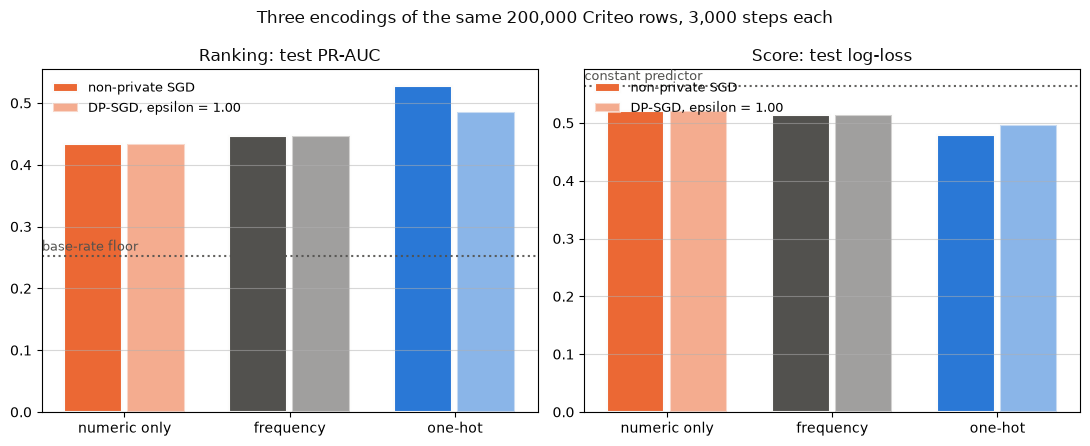

In [13]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4.5))
positions = np.arange(len(ENCODINGS))
width = 0.38

for axis, attribute, title, floor, floor_label in (
    (left, "pr_auc", "Ranking: test PR-AUC", base_rate, "base-rate floor"),
    (right, "loss", "Score: test log-loss", CONST.loss, "constant predictor"),
):
    by_arm = {arm: [chosen for chosen in SELECTED if chosen.arm == arm]
              for arm in ("SGD", "DP-SGD")}
    for offset, (arm, alpha) in enumerate((("SGD", 1.0), ("DP-SGD", 0.55))):
        heights = [getattr(chosen.test, attribute) for chosen in by_arm[arm]]
        colours = [encoding.colour for encoding in ENCODINGS]
        axis.bar(positions + (offset - 0.5) * width, heights, width * 0.92,
                 color=colours, alpha=alpha, edgecolor=SURFACE, linewidth=1.5,
                 label=("non-private SGD" if arm == "SGD"
                        else f"DP-SGD, epsilon = {spent:.2f}"))
    axis.axhline(floor, color=MUTED, linestyle=":", alpha=0.9)
    axis.annotate(floor_label, xy=(positions[0] - 0.5, floor), xytext=(0, 4),
                  textcoords="offset points", color=MUTED, fontsize=9)
    axis.set_xticks(positions)
    axis.set_xticklabels([encoding.name for encoding in ENCODINGS])
    axis.set_title(title, color=INK)
    axis.grid(alpha=0.5, axis="y")
    axis.legend(loc="upper left", frameon=False, fontsize=9)

# The bars are coloured by encoding and shaded by arm, so the legend's two
# entries describe the shading only; the solid pair and the pale pair are the
# same three colours in the same order.
fig.suptitle(f"Three encodings of the same {len(Y_TEST):,} Criteo rows, "
             f"{STEPS:,} steps each", color=INK)
fig.tight_layout()
plt.show()

### Reading the six cells

**One-hot wins, and it wins by more than privacy costs.** Private one-hot
reaches PR-AUC 0.4856 against non-private frequency's 0.4464 and non-private
numeric-only's 0.4332 — so the encoding, paid for at ε = 1, beats both dense
encodings' noiseless ceilings. The log-loss column orders them the same way:
0.4972 against 0.5130 and 0.5198.

**The frequency encoding recovers about a seventh of what the categorical
columns carry.** Dropping all 26 costs 0.0949 of PR-AUC against one-hot
(0.4332 against 0.5281, both non-private); replacing them with their
train-split frequencies buys back 0.0132 of that, which is 14% of the gap. The
decomposition says it in the column that matters — resolution 0.0461
numeric-only, 0.0518 frequency, 0.0853 one-hot. Two categories that occur
equally often become the same number, and on this file that collapse discards
most of what the columns hold.

**Privacy is nearly free on the dense arms and is not on the wide one.**
Numeric-only moves 0.4332 → 0.4333 of PR-AUC between its noiseless and its
private run and frequency 0.4464 → 0.4468, both inside the fourth decimal.
One-hot pays 0.5281 → 0.4856, and 0.0853 → 0.0667 of resolution: about a fifth
of its signal. That is section 2's arithmetic arriving. The perturbation's
length grows like `σ C √d`, 206 times longer at 551,947 coordinates than at 13,
and this is what that costs — the wide encoding loses what it was predicted to
lose and wins anyway.

**None of this is calibration.** Every arm's calibration term is at or under
0.0014 and every ECE at or under 0.0198, so the whole spread in log-loss is
resolution. No arm is trading calibration away for signal.

## What this shows, and what it does not

Three encodings of the same 200,000 Criteo test rows, each tuned on its own
copy of one grid over the same 100,000 validation rows, and each run twice —
once at its noiseless ceiling, once at ε = 1, δ = 1e-7 over 3,000 steps.

**The one-hot encoding is worth more than the privacy it costs** at this
budget: 0.4856 of PR-AUC with the noise on, against 0.4464 and 0.4332 for the
two dense encodings with no noise at all. **The frequency encoding is worth
about a seventh of one-hot** over dropping the categorical columns outright,
so it is much closer to discarding those 26 columns than to encoding them.

**The one confound cuts towards the arms that lost.** The two dense arms
standardize and the one-hot arm cannot, because centring a one-hot column
fills it (ADR-0020). No feature-norm bound is applied anywhere here, so
ADR-0013's interaction between standardizing and a cap is not in play and the
standardization is a fitted preprocessing step the dense arms receive and
one-hot does not. It therefore cannot explain a result in one-hot's favour;
what it could do is narrow the gap that was measured.

Not shown, and not claimed:

- **The clip axis is nearly inert here.** `C = 3` already exceeds one-hot's
  largest per-sample gradient norm of 2.888, and `C = 10` sits above every
  arm's 99th percentile, so over most of the grid the clip is not binding and
  `C` moves the noise scale alone. Every private arm selected `C = 10`, the
  top of the grid, which given the above reads as the selection being
  indifferent rather than as a preference for it. This notebook does not
  resolve that, and a grid that priced the clip properly would have to run
  below 1.0.
- **One-hot's noiseless arm selected `lr = 1.0`, the top of the grid.** Its
  ceiling is a lower bound for that reason, so the encoding gap above is if
  anything understated.
- **One seed, one split.** Every cell is a single run from a single
  initialization at `seed=0` and nothing here carries an error bar. The
  fourth-decimal moves the two dense arms show between their private and
  noiseless runs are well inside what a second seed could produce, which is
  why they are read as "nothing" rather than as a measured zero.
- **The preprocessing statistics are unaccounted** (ADR-0008) — the medians,
  the frequencies, the means and standard deviations, and on the one-hot arm
  the vocabulary, 551,947 columns whose existence and order are a function of
  the training rows. The ε covers the training loop only.
- **The grid searches are unaccounted.** Unlike a tuning notebook the
  selection here reads validation rows and reports the test split, so the
  figures are not optimistic the way a test-selected sweep's are; they are
  still unpaid for as a privacy matter.
- **δ = 1e-7 is this notebook's alone.** It is below `1/n` and is not the
  `1/n²` `bias_reduced_sgd` asks for, so these numbers are not readable
  against the bias-reduced-SGD comparison's.
- **The DP-SGD-vs-SGD-baseline comparison stays on the frequency encoding.**
  Nothing here moves it. It prices a different question — what privacy costs
  against a non-private baseline — and its numbers are its own.